In [5]:
import pandas as pd

# Example: January 2025 Yellow Taxi data
url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet"
df_taxi = pd.read_parquet(url)

print(df_taxi.shape)
df_taxi.head()

(3475226, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [7]:
# Make a copy of the dataframe
df_taxi_c = df_taxi.copy()

In [8]:
print(df_taxi_c['tpep_pickup_datetime'].dt.to_period('M').value_counts())

tpep_pickup_datetime
2025-01    3475204
2024-12         21
2025-02          1
Freq: M, Name: count, dtype: int64


In [9]:
df_taxi_c = df_taxi_c[
    (df_taxi_c['tpep_pickup_datetime'] >= '2025-01-01') &
    (df_taxi_c['tpep_pickup_datetime'] < '2025-02-01')
]

print(df_taxi_c.shape)
print(df_taxi_c['tpep_pickup_datetime'].min())
print(df_taxi_c['tpep_pickup_datetime'].max())

(3475204, 20)
2025-01-01 00:00:00
2025-01-31 23:59:59


In [10]:
print(df_taxi_c['tpep_pickup_datetime'].dt.to_period('M').value_counts())

tpep_pickup_datetime
2025-01    3475204
Freq: M, Name: count, dtype: int64


In [11]:
df_taxi_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3475204 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            floa

In [12]:
# Downcast numeric columns
for col in df_taxi_c.select_dtypes(include=['float64']).columns:
    df_taxi_c[col] = pd.to_numeric(df_taxi_c[col], downcast='float')

for col in df_taxi_c.select_dtypes(include=['int64']).columns:
    df_taxi_c[col] = pd.to_numeric(df_taxi_c[col], downcast='integer')

In [13]:
#Convert to Int using binart 0/1
df_taxi_c['store_and_fwd_flag'] = df_taxi_c['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

In [14]:
df_taxi_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3475204 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float32       
 4   trip_distance          float64       
 5   RatecodeID             float32       
 6   store_and_fwd_flag     float64       
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int8          
 10  fare_amount            float64       
 11  extra                  float32       
 12  mta_tax                float32       
 13  tip_amount             float32       
 14  tolls_amount           float32       
 15  improvement_surcharge  float32       
 16  total_amount           float64       
 17  congestion_surcharge   float32       
 18  Airport_fee            floa

In [15]:
#Check for missing values
df_taxi_c.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

In [16]:
missing = df_taxi_c.isnull().sum()
missing_percent = (missing / len(df_taxi_c)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

                      Missing Count  Percentage
passenger_count              540149   15.542944
RatecodeID                   540149   15.542944
store_and_fwd_flag           540149   15.542944
congestion_surcharge         540149   15.542944
Airport_fee                  540149   15.542944


In [17]:
# Median for passenger_count
df_taxi_c['passenger_count'] = df_taxi_c['passenger_count'].fillna(
    df_taxi_c['passenger_count'].median()
)

# Mode for RatecodeID
df_taxi_c['RatecodeID'] = df_taxi_c['RatecodeID'].fillna(
    df_taxi_c['RatecodeID'].mode()[0]
)

# Mode for store_and_fwd_flag
df_taxi_c['store_and_fwd_flag'] = df_taxi_c['store_and_fwd_flag'].fillna(
    df_taxi_c['store_and_fwd_flag'].mode()[0]
)

# Median for congestion_surcharge
df_taxi_c['congestion_surcharge'] = df_taxi_c['congestion_surcharge'].fillna(
    df_taxi_c['congestion_surcharge'].median()
)

# Median for Airport_fee
df_taxi_c['Airport_fee'] = df_taxi_c['Airport_fee'].fillna(
    df_taxi_c['Airport_fee'].median()
)

In [18]:
df_taxi_c[['passenger_count', 'RatecodeID', 'store_and_fwd_flag',
    'congestion_surcharge', 'Airport_fee']].isnull().sum()

passenger_count         0
RatecodeID              0
store_and_fwd_flag      0
congestion_surcharge    0
Airport_fee             0
dtype: int64

In [19]:
df_taxi_c.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,0.0,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,0.0,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,0.0,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,0.0,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,0.0,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [20]:
df_taxi_c[df_taxi_c['fare_amount'] < 0]['fare_amount'].value_counts()

fare_amount
-4.75     60598
-4.00      9782
-1.50      6919
-3.00      4553
-70.00     3631
          ...  
-28.94        1
-20.81        1
-10.16        1
-10.06        1
-15.11        1
Name: count, Length: 2527, dtype: int64

In [21]:
df_taxi_c[df_taxi_c['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
17,2,2025-01-01 00:01:41,2025-01-01 00:07:14,1.0,0.71,1.0,0.0,79,107,2,-7.20,-1.0,-0.5,3.66,0.0,-1.0,-8.54,-2.5,0.0,0.00
22,2,2025-01-01 00:55:54,2025-01-01 01:00:38,1.0,0.69,1.0,0.0,137,233,4,-6.50,-1.0,-0.5,0.00,0.0,-1.0,-11.50,-2.5,0.0,0.00
104,2,2025-01-01 00:56:12,2025-01-01 01:15:00,1.0,0.97,1.0,0.0,161,170,4,-16.30,-1.0,-0.5,0.00,0.0,-1.0,-21.30,-2.5,0.0,0.00
149,2,2025-01-01 00:55:53,2025-01-01 01:06:49,1.0,1.42,1.0,0.0,79,45,2,-12.10,-1.0,-0.5,0.00,0.0,-1.0,-17.10,-2.5,0.0,0.00
202,2,2025-01-01 00:29:35,2025-01-01 00:36:02,1.0,0.60,1.0,0.0,79,148,4,-7.20,-1.0,-0.5,0.00,0.0,-1.0,-12.20,-2.5,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3475198,2,2025-01-31 23:30:26,2025-01-31 23:36:41,1.0,1.21,1.0,0.0,49,17,0,-1.50,0.0,0.5,0.00,0.0,1.0,1.00,2.5,0.0,0.00
3475204,2,2025-01-31 23:33:05,2025-01-31 23:46:21,1.0,2.55,1.0,0.0,144,170,0,-4.75,0.0,0.5,0.00,0.0,1.0,4.91,2.5,0.0,0.75
3475205,2,2025-01-31 23:43:55,2025-01-31 23:48:40,1.0,0.45,1.0,0.0,231,45,0,-4.75,0.0,0.5,0.00,0.0,1.0,3.00,2.5,0.0,0.75
3475212,2,2025-01-31 23:00:46,2025-01-31 23:12:08,1.0,1.51,1.0,0.0,230,229,0,-4.75,0.0,0.5,0.00,0.0,1.0,2.07,2.5,0.0,0.75


In [22]:
df_taxi_c = df_taxi_c[df_taxi_c['fare_amount'] >= 0]

In [23]:
df_taxi_c[df_taxi_c['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee


In [24]:
df_taxi_c = df_taxi_c[df_taxi_c['total_amount'] >= 0]

In [25]:
df_taxi_c.head(12)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,0.0,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,0.0,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,0.0,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,0.0,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,0.0,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0
5,2,2025-01-01 00:48:24,2025-01-01 01:08:26,2.0,2.63,1.0,0.0,239,68,2,19.1,1.0,0.5,0.00,0.0,1.0,24.10,2.5,0.0,0.0
6,1,2025-01-01 00:14:47,2025-01-01 00:16:15,0.0,0.40,1.0,0.0,170,170,1,4.4,3.5,0.5,2.35,0.0,1.0,11.75,2.5,0.0,0.0
7,1,2025-01-01 00:39:27,2025-01-01 00:51:51,0.0,1.60,1.0,0.0,234,148,1,12.1,3.5,0.5,2.00,0.0,1.0,19.10,2.5,0.0,0.0
8,1,2025-01-01 00:53:43,2025-01-01 01:13:23,0.0,2.80,1.0,0.0,148,170,1,19.1,3.5,0.5,3.00,0.0,1.0,27.10,2.5,0.0,0.0
9,2,2025-01-01 00:00:02,2025-01-01 00:09:36,1.0,1.71,1.0,0.0,237,262,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.0,0.0


In [26]:
# Create drop-off date/time features
df_taxi_c['dropoff_year'] = df_taxi_c['tpep_dropoff_datetime'].dt.year
df_taxi_c['dropoff_month'] = df_taxi_c['tpep_dropoff_datetime'].dt.month
df_taxi_c['dropoff_day'] = df_taxi_c['tpep_dropoff_datetime'].dt.day
df_taxi_c['dropoff_day_of_week'] = df_taxi_c['tpep_dropoff_datetime'].dt.day_name()
df_taxi_c['dropoff_hour'] = df_taxi_c['tpep_dropoff_datetime'].dt.hour

# Weekend / Weekday
df_taxi_c['dropoff_day_type'] = df_taxi_c['tpep_dropoff_datetime'].dt.dayofweek.map(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

In [27]:
# Create pickup date/time features for pickup datatime
df_taxi_c['pickup_year'] = df_taxi_c['tpep_pickup_datetime'].dt.year
df_taxi_c['pickup_month'] = df_taxi_c['tpep_pickup_datetime'].dt.month
df_taxi_c['pickup_day'] = df_taxi_c['tpep_pickup_datetime'].dt.day
df_taxi_c['pickup_day_of_week'] = df_taxi_c['tpep_pickup_datetime'].dt.day_name()
df_taxi_c['pickup_hour'] = df_taxi_c['tpep_pickup_datetime'].dt.hour

# Weekend / Weekday
df_taxi_c['pickup_day_type'] = df_taxi_c['tpep_pickup_datetime'].dt.dayofweek.map(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

In [28]:
df_taxi_c[
    ['tpep_dropoff_datetime',
     'dropoff_year',
     'dropoff_month',
     'dropoff_day',
     'dropoff_day_of_week',
     'dropoff_hour',
     'dropoff_day_type']
].head()

,tpep_dropoff_datetime,dropoff_year,dropoff_month,dropoff_day,dropoff_day_of_week,dropoff_hour,dropoff_day_type
0,2025-01-01 00:26:59,2025,1,1,Wednesday,0,Weekday
1,2025-01-01 00:35:13,2025,1,1,Wednesday,0,Weekday
2,2025-01-01 00:46:01,2025,1,1,Wednesday,0,Weekday
3,2025-01-01 00:20:01,2025,1,1,Wednesday,0,Weekday
4,2025-01-01 00:25:06,2025,1,1,Wednesday,0,Weekday


In [29]:
df_taxi_c[
    ['tpep_pickup_datetime',
     'pickup_year',
     'pickup_month',
     'pickup_day',
     'pickup_day_of_week',
     'pickup_hour',
     'pickup_day_type']
].head()

,tpep_pickup_datetime,pickup_year,pickup_month,pickup_day,pickup_day_of_week,pickup_hour,pickup_day_type
0,2025-01-01 00:18:38,2025,1,1,Wednesday,0,Weekday
1,2025-01-01 00:32:40,2025,1,1,Wednesday,0,Weekday
2,2025-01-01 00:44:04,2025,1,1,Wednesday,0,Weekday
3,2025-01-01 00:14:27,2025,1,1,Wednesday,0,Weekday
4,2025-01-01 00:21:34,2025,1,1,Wednesday,0,Weekday


In [30]:
df_taxi_c.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,dropoff_day,dropoff_day_of_week,dropoff_hour,dropoff_day_type,pickup_year,pickup_month,pickup_day,pickup_day_of_week,pickup_hour,pickup_day_type
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,0.0,229,237,1,...,1,Wednesday,0,Weekday,2025,1,1,Wednesday,0,Weekday
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,0.0,236,237,1,...,1,Wednesday,0,Weekday,2025,1,1,Wednesday,0,Weekday
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,0.0,141,141,1,...,1,Wednesday,0,Weekday,2025,1,1,Wednesday,0,Weekday
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,0.0,244,244,2,...,1,Wednesday,0,Weekday,2025,1,1,Wednesday,0,Weekday
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,0.0,244,116,2,...,1,Wednesday,0,Weekday,2025,1,1,Wednesday,0,Weekday


In [31]:
df_taxi_c.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee', 'dropoff_year', 'dropoff_month', 'dropoff_day',
       'dropoff_day_of_week', 'dropoff_hour', 'dropoff_day_type',
       'pickup_year', 'pickup_month', 'pickup_day', 'pickup_day_of_week',
       'pickup_hour', 'pickup_day_type'],
      dtype='object')

In [32]:
# Number of Taxi Trips by Hour
hourly_trips = df_taxi_c.groupby('pickup_hour').size().reset_index(name='trips')

hourly_trips['hour_label'] = pd.to_datetime(
    hourly_trips['pickup_hour'], format='%H'
).dt.strftime('%I %p')

fig = px.bar(
    hourly_trips,
    x='hour_label',
    y='trips',
    title='Number of Taxi Trips by Hour',
    labels={
        'hour_label': 'Hour of Day',
        'trips': 'Number of Trips'
    }
)

fig.update_layout(
    xaxis={'categoryorder': 'array', 'categoryarray': hourly_trips['hour_label']}
)

fig.show()

In [33]:
# Number of Taxi Trips by Day of Week

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_trips = (
    df_taxi_c['pickup_day_of_week']
    .value_counts()
    .reindex(day_order)
    .reset_index()
)

day_trips.columns = ['day', 'trips']

fig = px.bar(
    day_trips,
    x='day',
    y='trips',
    title='Number of Taxi Trips by Day of Week',
    labels={
        'day': 'Day',
        'trips': 'Number of Trips'
    }
)

fig.show()

In [34]:
# Number of Taxi Trips by Day in January

daily_trips = (
    df_taxi_c.groupby('pickup_day')
    .size()
    .reset_index(name='trips')
)

fig = px.bar(
    daily_trips,
    x='pickup_day',
    y='trips',
    title='Number of Taxi Trips by Day in January',
    labels={
        'pickup_day': 'Day of January',
        'trips': 'Number of Trips'
    }
)

fig.show()

In [35]:
# Taxi trips Weekday vs Weekend
day_type = (
    df_taxi_c['pickup_day_type']
    .value_counts()
    .reset_index()
)

day_type.columns = ['day_type', 'trips']

fig = px.bar(
    day_type,
    x='day_type',
    y='trips',
    title='Taxi Trips: Weekday vs Weekend',
    labels={
        'day_type': 'Day Type',
        'trips': 'Number of Trips'
    }
)

fig.show()

In [36]:
# Total Taxi Revenue by Hour

hour_labels = [
    '12 AM', '1 AM', '2 AM', '3 AM', '4 AM', '5 AM',
    '6 AM', '7 AM', '8 AM', '9 AM', '10 AM', '11 AM',
    '12 PM', '1 PM', '2 PM', '3 PM', '4 PM', '5 PM',
    '6 PM', '7 PM', '8 PM', '9 PM', '10 PM', '11 PM'
]

hourly_revenue = (
    df_taxi_c.groupby('pickup_hour')['total_amount']
    .sum()
    .reset_index()
)

hourly_revenue['hour_label'] = hourly_revenue['pickup_hour'].map(
    dict(enumerate(hour_labels))
)

fig = px.bar(
    hourly_revenue,
    x='hour_label',
    y='total_amount',
    title='Total Taxi Revenue by Hour',
    labels={
        'hour_label': 'Hour of Day',
        'total_amount': 'Revenue ($)'
    }
)

fig.show()

In [37]:
# Total Taxi Revenue by Day in January

daily_revenue = (
    df_taxi_c.groupby('pickup_day')['total_amount']
    .sum()
    .reset_index()
)

fig = px.bar(
    daily_revenue,
    x='pickup_day',
    y='total_amount',
    title='Total Taxi Revenue by Day in January',
    labels={
        'pickup_day': 'Day of January',
        'total_amount': 'Revenue ($)'
    }
)

fig.show()

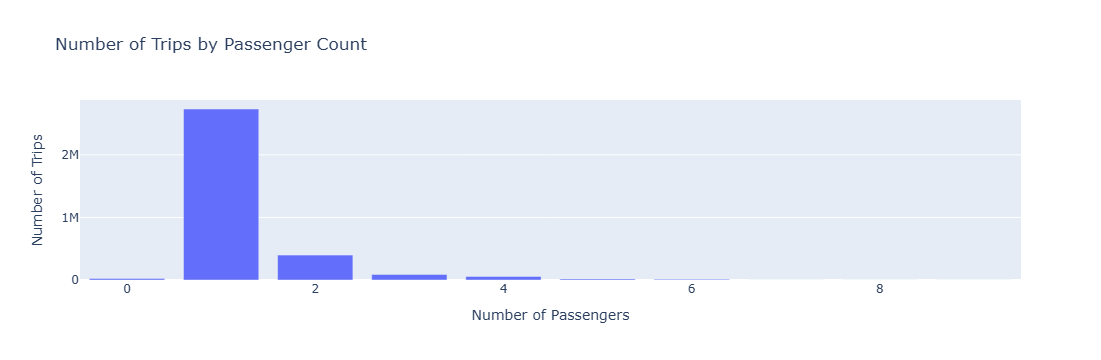

In [70]:
# Number of Trips by Passenger Count

passenger_counts = (
    df_taxi_c['passenger_count']
    .value_counts()
    .sort_index()
    .reset_index()
)

passenger_counts.columns = ['passenger_count', 'trips']

fig = px.bar(
    passenger_counts,
    x='passenger_count',
    y='trips',
    title='Number of Trips by Passenger Count',
    labels={
        'passenger_count': 'Number of Passengers',
        'trips': 'Number of Trips'
    }
)

fig.show()

In [39]:
top_pickup = (
    df_taxi_c['PULocationID']
    .value_counts()
    .head(10)
    .reset_index()
)

top_pickup.columns = ['pickup_location', 'trips']

fig = px.bar(
    top_pickup,
    x='pickup_location',
    y='trips',
    title='Top 10 Pickup Locations',
    labels={
        'pickup_location': 'Pickup Location ID',
        'trips': 'Number of Trips'
    }
)

fig.show()

In [40]:
top_dropoff = (
    df_taxi_c['DOLocationID']
    .value_counts()
    .head(10)
    .reset_index()
)

top_dropoff.columns = ['dropoff_location', 'trips']

fig = px.bar(
    top_dropoff,
    x='dropoff_location',
    y='trips',
    title='Top 10 Drop-off Locations',
    labels={
        'dropoff_location': 'Drop-off Location ID',
        'trips': 'Number of Trips'
    }
)

fig.show()

In [41]:
tip_payment = (
    df_taxi_c.groupby('payment_type')['tip_amount']
    .mean()
    .reset_index()
)

fig = px.bar(
    tip_payment,
    x='payment_type',
    y='tip_amount',
    title='Average Tip Amount by Payment Type',
    labels={
        'payment_type': 'Payment Type',
        'tip_amount': 'Average Tip ($)'
    }
)

fig.show()

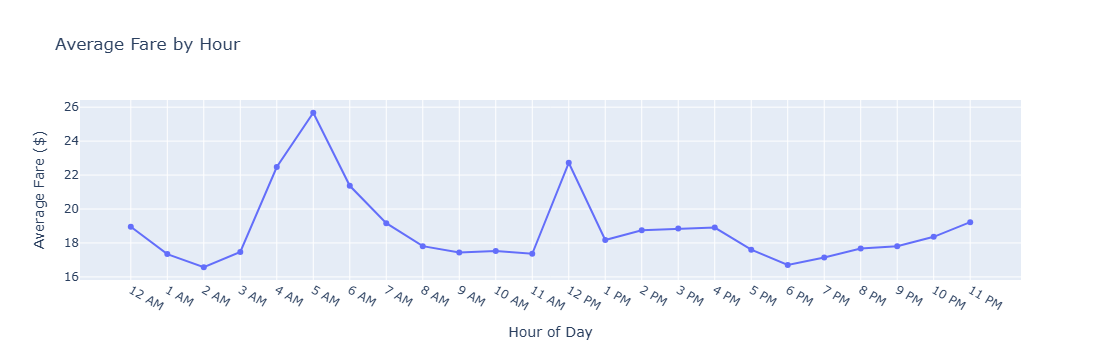

In [71]:
average_fare = (
    df_taxi_c.groupby('pickup_hour')['fare_amount']
    .mean()
    .reset_index()
)

average_fare['hour_label'] = average_fare['pickup_hour'].map(
    dict(enumerate(hour_labels))
)

fig = px.line(
    average_fare,
    x='hour_label',
    y='fare_amount',
    markers=True,
    title='Average Fare by Hour',
    labels={
        'hour_label': 'Hour of Day',
        'fare_amount': 'Average Fare ($)'
    }
)

fig.show()

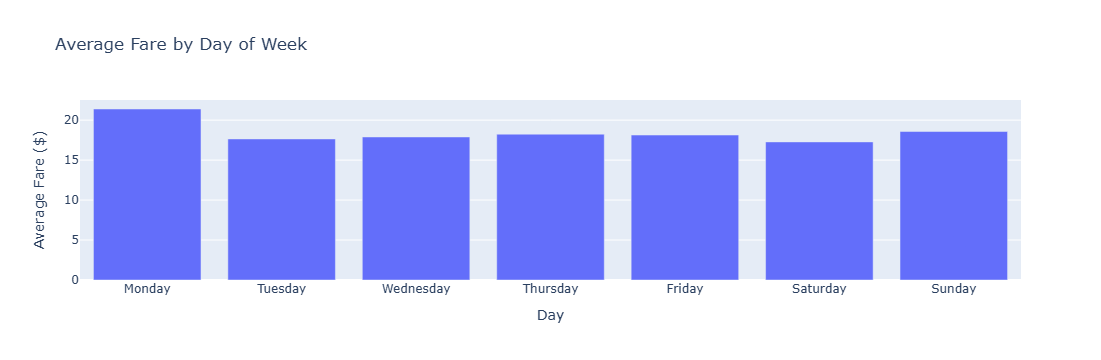

In [72]:
average_day_fare = (
    df_taxi_c.groupby('pickup_day_of_week')['fare_amount']
    .mean()
    .reindex(day_order)
    .reset_index()
)

fig = px.bar(
    average_day_fare,
    x='pickup_day_of_week',
    y='fare_amount',
    title='Average Fare by Day of Week',
    labels={
        'pickup_day_of_week': 'Day',
        'fare_amount': 'Average Fare ($)'
    }
)

fig.show()

In [44]:
df_taxi_c['passenger_count'].value_counts().sort_index()

passenger_count
0.0      24651
1.0    2733048
2.0     397720
3.0      89056
4.0      56591
5.0      17717
6.0      11964
7.0          4
8.0         11
9.0          3
Name: count, dtype: int64

In [45]:
df_taxi_c[df_taxi_c['passenger_count'] == 0].head(20).T

,6,7,8,94,95,96,97,173,174,175,404,510,706,707,1430,1431,1432,1626,2252,2418
VendorID,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
tpep_pickup_datetime,2025-01-01 00:14:47,2025-01-01 00:39:27,2025-01-01 00:53:43,2025-01-01 00:11:27,2025-01-01 00:19:30,2025-01-01 00:33:13,2025-01-01 00:45:05,2025-01-01 00:01:44,2025-01-01 00:14:06,2025-01-01 00:52:53,2025-01-01 00:53:43,2025-01-01 00:38:57,2025-01-01 00:42:42,2025-01-01 00:45:41,2025-01-01 00:15:28,2025-01-01 00:25:37,2025-01-01 00:53:46,2025-01-01 00:53:12,2025-01-01 00:11:23,2025-01-01 00:23:16
tpep_dropoff_datetime,2025-01-01 00:16:15,2025-01-01 00:51:51,2025-01-01 01:13:23,2025-01-01 00:16:58,2025-01-01 00:27:25,2025-01-01 00:40:08,2025-01-01 01:20:32,2025-01-01 00:08:38,2025-01-01 00:32:34,2025-01-01 01:01:04,2025-01-01 01:00:47,2025-01-01 00:46:12,2025-01-01 00:42:44,2025-01-01 01:04:59,2025-01-01 00:23:15,2025-01-01 00:36:28,2025-01-01 01:05:35,2025-01-01 01:13:49,2025-01-01 00:57:37,2025-01-01 00:34:50
passenger_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
trip_distance,0.4,1.6,2.8,0.7,1.0,1.2,1.8,0.9,2.1,1.5,0.8,1.2,0.0,4.7,1.2,1.8,2.2,2.4,3.6,2.9
RatecodeID,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
store_and_fwd_flag,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PULocationID,170,234,148,144,211,158,68,113,148,249,163,170,261,261,142,239,142,148,48,107
DOLocationID,170,148,170,211,158,68,50,148,164,246,161,79,261,170,239,263,141,90,229,141
payment_type,1,1,1,1,1,1,1,1,1,1,2,2,1,3,1,1,3,1,1,1


Machine Learning

In [46]:
df_taxi_ml= df_taxi_c.copy()

In [47]:
fare_components = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'Airport_fee',
    'cbd_congestion_fee'
]
df_taxi_ml.drop(columns=fare_components, inplace=True)

In [48]:
drop_columns = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'dropoff_year',
    'dropoff_month',
    'dropoff_day',
    'dropoff_day_of_week',
    'dropoff_hour',
    'dropoff_day_type'
]
df_taxi_ml.drop(columns=drop_columns, inplace=True)

In [49]:
df_taxi_ml.columns

Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type',
       'total_amount', 'pickup_year', 'pickup_month', 'pickup_day',
       'pickup_day_of_week', 'pickup_hour', 'pickup_day_type'],
      dtype='object')

In [50]:
df_taxi_ml.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,total_amount,pickup_year,pickup_month,pickup_day,pickup_hour
count,3.330765e+06,3.330765e+06,3.330765e+06,3.330765e+06,3.330765e+06,3.330765e+06,3.330765e+06,3.330765e+06,3.330765e+06,3330765.0,3330765.0,3.330765e+06,3.330765e+06
mean,1.776122e+00,1.255727e+00,5.387224e+00,2.301793e+00,2.295269e-03,1.654878e+02,1.644451e+02,1.020892e+00,2.712161e+01,2025.0,1.0,1.682302e+01,1.434095e+01
std,4.330766e-01,7.045885e-01,5.081820e+02,1.092686e+01,4.785395e-02,6.438339e+01,6.934009e+01,6.112847e-01,4.735223e+02,0.0,0.0,8.720204e+00,5.766927e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2025.0,1.0,1.000000e+00,0.000000e+00
25%,2.000000e+00,1.000000e+00,9.900000e-01,1.000000e+00,0.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,1.585000e+01,2025.0,1.0,1.000000e+01,1.100000e+01
50%,2.000000e+00,1.000000e+00,1.670000e+00,1.000000e+00,0.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,2.035000e+01,2025.0,1.0,1.700000e+01,1.500000e+01
75%,2.000000e+00,1.000000e+00,3.090000e+00,1.000000e+00,0.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.826000e+01,2025.0,1.0,2.400000e+01,1.900000e+01
max,7.000000e+00,9.000000e+00,2.761000e+05,9.900000e+01,1.000000e+00,2.650000e+02,2.650000e+02,5.000000e+00,8.633804e+05,2025.0,1.0,3.100000e+01,2.300000e+01


In [63]:
df_corr= df_taxi_ml.corr(numeric_only=True)['total_amount'].sort_values(ascending=False)
df_corr

total_amount          1.000000
trip_distance         0.923796
RatecodeID            0.067200
passenger_count       0.056208
VendorID              0.028602
pickup_hour           0.016169
payment_type          0.008236
store_and_fwd_flag   -0.003243
pickup_day           -0.023262
DOLocationID         -0.087962
PULocationID         -0.122474
pickup_year                NaN
pickup_month               NaN
Name: total_amount, dtype: float64

In [64]:
# Clean target variable boundaries
df_taxi_ml = df_taxi_ml[
    (df_taxi_ml['total_amount'] > 0) & 
    (df_taxi_ml['total_amount'] <= 300)  
]

In [65]:
# Clean reasonable physical limits
df_taxi_ml = df_taxi_ml[
    (df_taxi_ml['trip_distance'] > 0) & 
    (df_taxi_ml['trip_distance'] <= 100) &  
    (df_taxi_ml['passenger_count'] > 0) & 
    (df_taxi_ml['passenger_count'] <= 6)
]

In [73]:
# Numerical columns
numerical_features = [
    'VendorID',
    'passenger_count',
    'trip_distance',
    'RatecodeID',
    'store_and_fwd_flag',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'pickup_year',
    'pickup_month',
    'pickup_day',
    'pickup_hour'
]

In [74]:
# Define the categorical columns to encode
categorical_features = ['pickup_day_of_week', 'pickup_day_type']

In [75]:
# Build the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' 
)

In [76]:
# 3. Ensure Pandas DataFrame output (preserves column names)
preprocessor.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['pickup_day_of_week', 'pickup_day_type'])])

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'X' is not defined

In [77]:
# Fit and transform your training set
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

NameError: name 'X_train' is not defined

In [ ]:
# Define Target (y) and Features (X)
X = df_taxi_ml[numerical_features + categorical_features]
y = df_taxi_ml['total_amount']

In [69]:
# Split into Train and Test sets FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

NameError: name 'X' is not defined

In [ ]:
# Fit model and evaluate using LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_encoded, y_train)

In [ ]:
cdf = pd.DataFrame(
    data=lr_model.coef_,
    index=X_train_encoded.columns,
    columns=["Coefficient ($)"]
).sort_values(by="Coefficient ($)", ascending=False)
print(cdf)

In [ ]:
# Sort coefficients
coef_df = coef_df.sort_values('coefficient')

plt.figure(figsize=(12, 10))

plt.barh(
    coef_df['feature'],
    coef_df['coefficient']
)

plt.axvline(x=0, linewidth=1)

plt.title('Linear Regression Coefficients', fontsize=16)
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Generate predictions on the encoded test set
lr_pred = lr_model.predict(X_test_encoded)

In [ ]:
lr_pred

In [ ]:
# 1. Store test actuals and predictions in a DataFrame
df_pred = pd.DataFrame({
    'y_test': y_test,
    'lm_pred': lr_pred
})

# 2. Compute plot bounds for the perfect prediction line
min_val = min(df_pred['y_test'].min(), df_pred['lm_pred'].min())
max_val = max(df_pred['y_test'].max(), df_pred['lm_pred'].max())

# 3. Create the figure and axis
plt.figure(figsize=(10, 6), dpi=100)

# Scatter plot for predictions
plt.scatter(
    df_pred['y_test'], 
    df_pred['lm_pred'], 
    color='royalblue', 
    alpha=0.6, 
    edgecolors='none', 
    s=40,
    label='Predictions'
)

# Perfect prediction line (y = x)
plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='crimson', 
    linestyle='--', 
    linewidth=2, 
    label='Perfect prediction'
)

# 4. Formatting and labeling
plt.title('Model Predictions vs Actual Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)

# Format axes ticks to show currency style ($)
plt.gca().xaxis.set_major_formatter('${x:,.2f}')
plt.gca().yaxis.set_major_formatter('${x:,.2f}')

# Aesthetics
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, lr_pred)
mse = mean_squared_error(y_test, lr_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, lr_pred)

In [ ]:
#  Print out the results
print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R² Score):          {r2:.4f} ({r2*100:.2f}% of variance explained)")

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [61]:
hist_gb = HistGradientBoostingRegressor(
    max_iter=100,             
    learning_rate=0.1,
    random_state=42,
    categorical_features=None
)

NameError: name 'HistGradientBoostingRegressor' is not defined

In [ ]:
hist_gb.fit(X_train_encoded, y_train)

In [ ]:
hist_pred = hist_gb.predict(X_test_encoded)
hist_pred

In [ ]:
print(f"MAE:  ${mean_absolute_error(y_test, hist_pred):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, hist_pred)):.2f}")
print(f"R²:   {r2_score(y_test, hist_pred):.4f}")

print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R² Score):          {r2:.4f} ({r2*100:.2f}% of variance explained)")

In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    n_jobs=-1,          
    random_state=42,
    verbose=-1
)

In [ ]:
lgb_model.fit(X_train_encoded,y_train)

In [ ]:
lgb_pred = lgb_model.predict(X_test_encoded)
lgb_pred

In [ ]:
print(f"MAE:  ${mean_absolute_error(y_test, lgb_pred):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, lgb_pred)):.2f}")
print(f"R²:   {r2_score(y_test, lgb_pred):.4f}")

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': lgb_pred
})

comparison.head(10)

In [4]:
plt.figure(figsize=(9, 6), dpi=100)

# Scatter plot of actual vs predicted
plt.scatter(y_test, hist_pred, alpha=0.25, color='seagreen', edgecolors='none', s=25, label='LightGBM Predictions')

# Perfect prediction line (y = x)
min_val = min(y_test.min(), hist_pred.min())
max_val = max(y_test.max(), hist_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.8, label='Perfect Fit (Y = X)')

# Formatting
plt.title('Final Model: Actual vs. Predicted Fare ($)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Actual Fare ($)', fontsize=11)
plt.ylabel('Predicted Fare ($)', fontsize=11)
plt.gca().xaxis.set_major_formatter('${x:,.2f}')
plt.gca().yaxis.set_major_formatter('${x:,.2f}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [306]:
#Check for overfitting
train_p= lgb_model.predict(X_train_encoded)
test_p= lgb_model.predict(X_test_encoded)

In [309]:
train_r2=r2_score(y_train,train_p)
test_r2=r2_score(y_test,test_p)

In [310]:
print(train_r2)
print(test_r2)

0.9504245353413036
0.9483944045609907


In [311]:
import joblib

# Save model and preprocessor to disk
joblib.dump(lgb_model, 'taxi_lgb_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [60]:
X

NameError: name 'X' is not defined